In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss
from sklearn.model_selection import train_test_split
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# Load the saved model, data
data = pd.read_csv("data_with_probs.csv")

In [3]:
def sample_play(df, completion = 0, route_type = None, route_group = None):
    '''
        Randomly samples a play (game_id, play_id) from plays based on specified
        parameters - completion, route_type/route_group
    '''

    # Filter to Completion Status
    possible_plays = df[df['complete'] == completion].copy()

    # Filter by route_type / route_group
    if route_type is not None:
        possible_plays = possible_plays[possible_plays['route_type'] == route_type]

    if route_group is not None:
        possible_plays = possible_plays[possible_plays['route_group'] == route_group]

    # Grab unique (game_id, play_id) combos
    plays = possible_plays[['game_id', 'play_id']].drop_duplicates()

    if len(plays) == 0:
        print("ERROR: No plays exist...")
        return None, None  # no matching play

    # Randomly sample one play
    sampled_play = plays.sample(n=1, random_state=None).iloc[0]

    return sampled_play['game_id'], sampled_play['play_id']

In [31]:
# Sample Play
game_id, play_id = sample_play(data, completion = 1, route_type = None, route_group = "INTERMEDIATE")
print(f"Game ID: {game_id} Play ID: {play_id}")

Game ID: 2023101507 Play ID: 2505


In [8]:
def completion_prob_change_distr_plot(df):
    '''
        Plot the distribution of Net In-Air Completion Probability Change
        for complete deep passes versus incomplete deep passes
    '''

    # Sum up completion probability change for each play in dataset
    play_cpc = df.groupby(['game_id', 'play_id']).agg({
                    'auc_slice': 'sum',
                    'complete': 'first'
                 }).reset_index()

    # Create a Figure to Plot on
    plt.figure(figsize=(10,6))

    # Plot Kernel Density Estimations (KDE) for complete versus incomplete
    comp_map = {0: 'red', 1:'green'}
    for comp, color in comp_map.items():
        # Grab plays of current completion status
        subset = play_cpc[play_cpc['complete'] == comp]

        # Add KDE Plot
        sns.kdeplot(
            subset['auc_slice'], 
            color=color, 
            label=f"{'Complete' if comp == 1 else 'Incomplete'} ({comp})",
            fill=True,
            alpha=0.5
        )

    plt.xlabel('Net Completion Probability Change (In-Air)')
    plt.ylabel('Density')
    plt.title('Distribution of Net Completion Probability Change by Play Outcome')
    plt.legend(title='Play Outcome')
    plt.show()

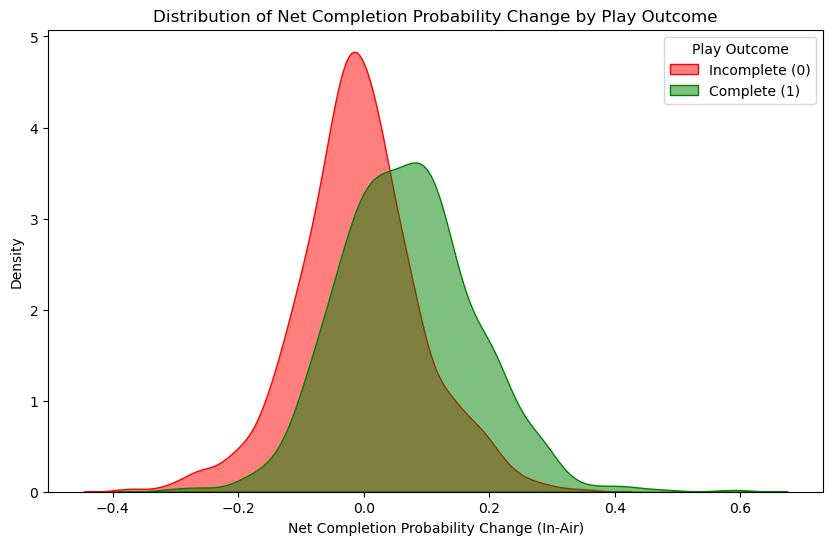

In [28]:
completion_prob_change_distr_plot(data)

**Analysis:** From this plot, it is apparent that there is more variance in the distribution of Net Completion Probability Change on completions then there is on incompletions. The distribution of values for incomplete passes is centered beneath zero, with a relatively high concentration of values at this center. The vast majority of net completion probability change values lie between -0.2 and 0.2 for incomplete passes, suggesting the possibility that incompletions often come from a minimal amount of probability improvement over the course of time where the ball is in the air. Completions, on the other hand, is centered above zero, with less concentration at its center, more widely distributed primarily throughout the values -0.1 and 0.3. This suggests that completions often are the result of general increase in catch probability with the ball in the air. Negative values for completions may be scenarios where there is a high completion probability at release of the ball, and the defenders work to marginally decrease completion probability while the ball is in the air.

In [29]:
def completion_prob_boxplot(df):
    '''
        For the purpose of analyzing how well the model performs
        at predicting completion vs. incompletion, this function
        creates 2 boxplots, one for completions, the other for incompletions,
        illustrating the distribution of values of average completion probability
        by the model after the ball is released.
    '''
    
    # Filter frames after release
    df_after = df[df['to_release'] == 'after'].copy()
    
    # Ensure 'complete' is integer
    df_after['complete'] = df_after['complete'].astype(int)
    
    # Aggregate average completion probability per play
    play_avg = df_after.groupby(['game_id', 'play_id']).agg({
        'completion_prob': 'mean',
        'complete': 'first'
    }).reset_index()
    
    # Create boxplot
    plt.figure(figsize=(8,6))
    sns.boxplot(
        data=play_avg, 
        x='complete', 
        y='completion_prob'
    )
    plt.xlabel('Complete')
    plt.ylabel('Average Predicted Completion Probability (In-Air)')
    plt.title('Distribution of Avg. Predicted Completion Probability per Play')
    plt.show()

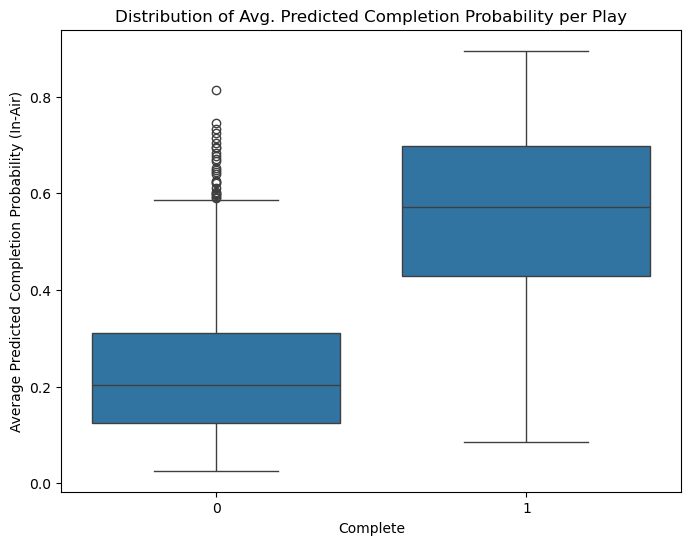

In [30]:
completion_prob_boxplot(data)

**Analysis:** These boxplots suggest some success in model building, indicating that in general, incompletions have a low average completion probability when the ball in the air, and completions have a high average completion probability when the ball is in the air. The width of the distributions for completions and incompletions indicates the model was regularized and overfitting was prevented, a goal in creating this model for analytical analysis without the objective of perfectly predicting the target 'complete' variable, and rather creating a smooth measurement in the range of 0 - 1 (incomplete - complete) indicative of completion probability on a frame by frame basis.

In [32]:
def rank_receivers_by_auc(df, min_plays=10):
    '''
        Returns a dataframe ranking receivers on their average Net In-Air
        Completion Probability Change for receivers with at least min_plays
        in the dataset.
    '''
    
    # Compute Net Completion Probability Change for each play in dataset
    play_level_cpc = df.groupby(['game_id', 'play_id', 'tgt_rec_name']).agg({
        'auc_slice': 'sum'
    }).reset_index()

    # Compute Average Net CPC for Each Receiver
    receiver_cpc = play_level_cpc.groupby('tgt_rec_name').agg(
        avg_ncpc_per_play = ('auc_slice', 'mean'),
        total_plays = ('auc_slice', 'count')
    ).reset_index()

    # Remove receivers with not enough minimum plays
    receiver_cpc = receiver_cpc[receiver_cpc['total_plays'] >= min_plays]

    # Sort from best to worst
    receiver_cpc = receiver_cpc.sort_values('avg_ncpc_per_play', ascending=False)

    return receiver_cpc

In [33]:
receiver_rankings = rank_receivers_by_auc(data, min_plays=10)
receiver_rankings.head(40)

,tgt_rec_name,avg_ncpc_per_play,total_plays
23,Brandon Aiyuk,0.075131,17
42,Chris Moore,0.074755,10
127,Jaylen Waddle,0.073091,12
109,Jahan Dotson,0.071988,10
55,D.J. Chark,0.071874,13
44,Christian Kirk,0.069769,12
248,Tutu Atwell,0.062704,14
122,Jameson Williams,0.062652,11
139,Josh Palmer,0.061079,11
155,Keenan Allen,0.059064,15
